# Лекция: Domain Shift + Наивный Байес + Метрики (демо + домашка)

Этот ноутбук рассчитан на **лекцию + практику** и состоит из двух частей.

## Часть A — Domain shift и различия распределений
- Смотрим, как меняются распределения текста между **темами / жанрами / стилями**
- Используем **log-odds** (лог-отношение вероятностей) для поиска токенов, которые лучше всего различают домены
- Заглядываем в несколько классических датасетов

## Часть B — Наивный байесовский классификатор и оценка качества
- Строим **классификатор авторов** на публичных текстах (Project Gutenberg)
- Обучаем **Multinomial Naive Bayes** (на counts), сравниваем с **TF-IDF + NB**
- Считаем метрики: accuracy, precision/recall/F1, macro vs micro
- Делаем **domain shift**: обучаем на прозе, тестируем на поэзии (те же авторы)

> Ноутбук Colab-friendly: скачивает данные из интернета.


In [ ]:
# Базовые библиотеки
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from typing import List, Tuple

# sklearn
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.rcParams["figure.dpi"] = 140
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Вспомогательные функции

Мы будем:
- токенизировать (простым regex),
- считать сглаженные **log-odds** между двумя доменами,
- резать длинные тексты на чанки,
- скачивать тексты с Project Gutenberg.


In [ ]:
TOKEN_RE = re.compile(r"[A-Za-z']+")

def simple_tokenize(text: str) -> List[str]:
    return TOKEN_RE.findall(text.lower())

def chunk_tokens(tokens: List[str], chunk_size: int = 200, min_frac: float = 0.5) -> List[str]:
    """Режем на чанки фиксированной длины; хвост сохраняем, если он >= min_frac*chunk_size."""
    chunks = []
    min_len = int(chunk_size * min_frac)
    for i in range(0, len(tokens), chunk_size):
        chunk = tokens[i:i+chunk_size]
        if len(chunk) >= min_len:
            chunks.append(" ".join(chunk))
    return chunks

def log_odds_with_smoothing(counts_a: Counter, counts_b: Counter, alpha: float = 0.1):
    """Δ(w)=log((c_a(w)+α)/(N_a+α|V|)) - log((c_b(w)+α)/(N_b+α|V|))"""
    vocab = set(counts_a) | set(counts_b)
    V = len(vocab)
    Na = sum(counts_a.values())
    Nb = sum(counts_b.values())
    deltas = {}
    for w in vocab:
        pa = (counts_a[w] + alpha) / (Na + alpha * V)
        pb = (counts_b[w] + alpha) / (Nb + alpha * V)
        deltas[w] = math.log(pa) - math.log(pb)
    return deltas

def top_log_odds_words(texts_a: List[str], texts_b: List[str], top_n: int = 25, alpha: float = 0.1):
    ca = Counter()
    cb = Counter()
    for t in texts_a:
        ca.update(simple_tokenize(t))
    for t in texts_b:
        cb.update(simple_tokenize(t))
    deltas = log_odds_with_smoothing(ca, cb, alpha=alpha)
    pos = sorted(deltas.items(), key=lambda x: x[1], reverse=True)[:top_n]
    neg = sorted(deltas.items(), key=lambda x: x[1])[:top_n]
    return pos, neg

def strip_gutenberg_header_footer(text: str) -> str:
    """Грубое (но часто рабочее) удаление шапки/подвала Gutenberg."""
    start = re.search(r"\*\*\* START OF (THIS|THE) PROJECT GUTENBERG EBOOK.*\*\*\*", text)
    end = re.search(r"\*\*\* END OF (THIS|THE) PROJECT GUTENBERG EBOOK.*\*\*\*", text)
    if start and end and start.end() < end.start():
        return text[start.end():end.start()]
    return text

def download_gutenberg_text(gutenberg_id: int) -> str:
    """Скачиваем текст по ID, пробуем несколько URL-шаблонов."""
    import requests
    candidates = [
        f"https://www.gutenberg.org/cache/epub/{gutenberg_id}/pg{gutenberg_id}.txt",
        f"https://www.gutenberg.org/files/{gutenberg_id}/{gutenberg_id}-0.txt",
        f"https://www.gutenberg.org/files/{gutenberg_id}/{gutenberg_id}.txt",
    ]
    last_err = None
    for url in candidates:
        try:
            r = requests.get(url, timeout=30)
            if r.status_code == 200 and len(r.text) > 1000:
                return strip_gutenberg_header_footer(r.text)
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Не удалось скачать Gutenberg ID={gutenberg_id}. Последняя ошибка: {last_err}")

def plot_length_hist(texts: List[str], title: str):
    lens = [len(simple_tokenize(t)) for t in texts]
    plt.figure()
    plt.hist(lens, bins=50, alpha=0.75)
    plt.title(title)
    plt.xlabel("длина документа (токены)")
    plt.ylabel("кол-во")
    plt.show()


# Часть A — Domain shift и различия распределений

## A1. 20 Newsgroups: темы как «домены»
Сначала возьмём **классический датасет** 20 Newsgroups https://scikit-learn.org/0.19/datasets/twenty_newsgroups.html#the-20-newsgroups-text-dataset.  
Мы возьмём 3 класса:
- политика,
- хоккей (спорт),
- техника (компьютерная графика).

Задачи:
1) вывести список классов и посмотреть примеры,
2) сравнить домены через log-odds,
3) посмотреть разницу распределений длины текстов.


In [ ]:
# A1) Загружаем 20 Newsgroups (3 класса)

categories = [
    'talk.politics.misc',   # политика
    'rec.sport.hockey',     # спорт
    'comp.graphics'   # техника (компьютерная графика)
]

news = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

texts = news.data
y = news.target
label_names = news.target_names

print("Классы:", label_names)
print("Всего документов:", len(texts))
print("Размеры классов:", dict(zip(*np.unique(y, return_counts=True))))

# Сплит: часть для анализа (train), часть для проверки (test)
X_train, X_test, y_train, y_test = train_test_split(
    texts, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)


Классы: ['comp.graphics', 'rec.sport.hockey', 'talk.politics.misc']
Всего документов: 2747
Размеры классов: {np.int64(0): np.int64(973), np.int64(1): np.int64(999), np.int64(2): np.int64(775)}


In [ ]:
# A2) Несколько примеров из каждого класса

import random
random.seed(RANDOM_STATE)

def show_examples_per_class(X, y, label_names, n=2, max_chars=400):
    for k, name in enumerate(label_names):
        idxs = [i for i, yy in enumerate(y) if yy == k]
        pick = random.sample(idxs, k=min(n, len(idxs)))
        print("="*80)
        print(f"Класс {k}: {name}  (показываю {len(pick)} примера)")
        for j, i in enumerate(pick, 1):
            ex = X[i].replace("\n", " ").strip()
            print(f"--- пример {j} ---")
            print(ex[:max_chars], "..." if len(ex) > max_chars else "")

show_examples_per_class(X_train, y_train, label_names, n=2)


Класс 0: comp.graphics  (показываю 2 примера)
--- пример 1 ---
Where could I find a description of the JPG file format?  Specifically I need to know where in a JPG file I can find the height and width of  the image, and perhaps even the number of colors being used.  Any suggestions?  Peter 
--- пример 2 ---
Wouldn't this require a hyper-sphere.  In 3-space, 4 points over specifies a sphere as far as I can see.  Unless that is you can prove that a point exists in 3-space that is equi-distant from the 4 points, and this may not necessarily happen.  Correct me if I'm wrong (which I quite possibly am!)  steve --- 
Класс 1: rec.sport.hockey  (показываю 2 примера)
--- пример 1 ---
I think that Mike Foligno was the captain of the Sabres when he got traded to the Leafs. Also, wasn't Rick Vaive the captain of the Leafs when he got traded to Chicago (with Steve Thomas for Ed Olcyzk and someone). Speaking of the Leafs, I believe that Darryl Sittler was their captain (he'd torn the "C" off his jer

In [ ]:
# A3) Log-odds: находим токены, различающие домены (попарно)

# Сравним: политика vs хоккей
texts_pol = [t for t, yy in zip(X_train, y_train) if yy == label_names.index('talk.politics.misc')]
texts_hoc = [t for t, yy in zip(X_train, y_train) if yy == label_names.index('rec.sport.hockey')]
pos, neg = top_log_odds_words(texts_pol, texts_hoc, top_n=25, alpha=0.1)

print("Топ-слова для politics (против hockey):")
display(pd.DataFrame(pos, columns=["word", "Δ(pol-hoc)"]))
print("Топ-слова для hockey (против politics):")
display(pd.DataFrame(neg, columns=["word", "Δ(pol-hoc)"]))

# Сравним: компьютерная vs хоккей (техника vs спорт)
texts_mus = [t for t, yy in zip(X_train, y_train) if yy == label_names.index('comp.graphics')]
pos2, neg2 = top_log_odds_words(texts_mus, texts_hoc, top_n=25, alpha=0.1)

print("Топ-слова для comp graphics (против hockey):")
display(pd.DataFrame(pos2, columns=["word", "Δ(technology-hoc)"]))
print("Топ-слова для hockey (против comp graphics):")
display(pd.DataFrame(neg2, columns=["word", "Δ(technology-hoc)"]))


Топ-слова для politics (против hockey):


,word,Δ(pol-hoc)
0,stephanopoulos,7.924356
1,myers,7.524553
2,ms,7.521226
3,war,6.730500
4,tax,6.662085
5,health,6.613727
6,law,6.588642
7,congress,6.490873
8,dee,6.318031
9,groups,6.318031


Топ-слова для hockey (против politics):


,word,Δ(pol-hoc)
0,season,-8.349126
1,pts,-8.177588
2,players,-8.121261
3,det,-8.116421
4,bos,-7.924446
5,tor,-7.792677
6,chi,-7.785947
7,nhl,-7.779172
8,flyers,-7.730416
9,puck,-7.671619


Топ-слова для comp graphics (против hockey):


,word,Δ(technology-hoc)
0,graphics,8.665924
1,image,8.560414
2,jpeg,7.837086
3,images,7.787971
4,pub,7.740097
5,ftp,7.724893
6,program,7.677844
7,data,7.544944
8,gif,7.453797
9,code,7.229523


Топ-слова для hockey (против comp graphics):


,word,Δ(technology-hoc)
0,hockey,-8.216933
1,season,-8.006246
2,pts,-7.834708
3,det,-7.773542
4,goal,-7.682154
5,bos,-7.581567
6,chi,-7.443068
7,nhl,-7.436293
8,flyers,-7.387537
9,puck,-7.328739


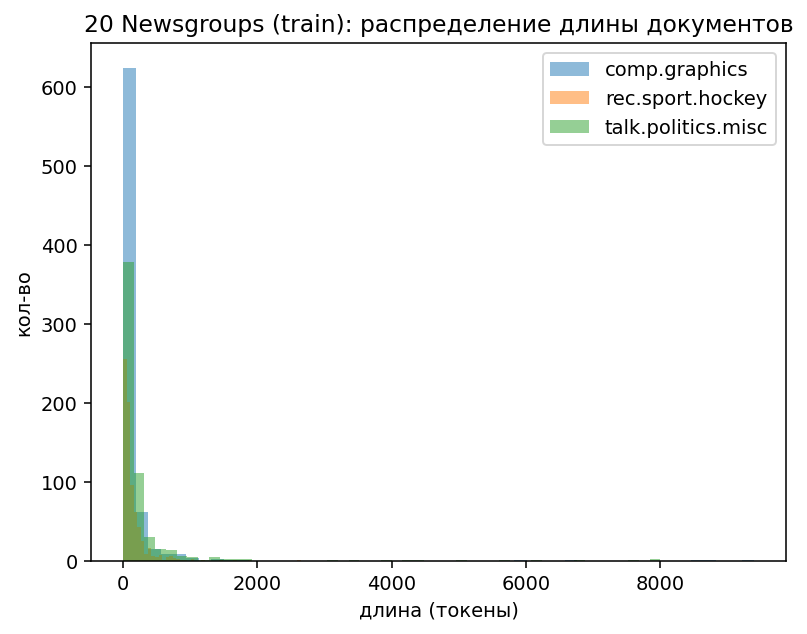

In [ ]:
# A4) Сравнение распределений: длина документов по доменам

df_len = pd.DataFrame({
    "len_tokens": [len(simple_tokenize(t)) for t in X_train],
    "domain": [label_names[yy] for yy in y_train]
})

plt.figure()
for dom, g in df_len.groupby("domain"):
    plt.hist(g["len_tokens"], bins=50, alpha=0.5, label=dom)

plt.legend()
plt.title("20 Newsgroups (train): распределение длины документов")
plt.xlabel("длина (токены)")
plt.ylabel("кол-во")
plt.show()


## A5. Ещё датасеты: sentiment и неформальные тексты

Задача: взять ещё 2 источника данных и посмотреть:
- log-odds (какие слова “сильнее всего” отличают домены),
- распределение длины текстов.

Мы возьмём:
1) **Sentiment**: IMDb (длинные отзывы о фильмах)
2) **Неформальные тексты**: TweetEval (короткие твиты)

Для этого используем библиотеку `datasets` (HuggingFace).


In [ ]:
# Установка datasets (в Colab может занять 30-60 секунд)
!pip -q install datasets

from datasets import load_dataset


In [ ]:
# A5.1) Загружаем IMDb (sentiment) и TweetEval (неформальные тексты)

imdb = load_dataset("imdb")
tweet = load_dataset("tweet_eval", "sentiment")  # твиты с метками тональности

print("IMDb splits:", imdb)
print("TweetEval splits:", tweet)
print("IMDb example:", imdb["train"][0]["text"][:200])
print("Tweet example:", tweet["train"][0]["text"])


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

...

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

IMDb splits: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
TweetEval splits: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
IMDb example: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev
Tweet example: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"


In [ ]:
# A5.2) Берём небольшие подвыборки, чтобы всё быстро работало

def sample_texts(ds, split, n=2000, text_key="text"):
    idx = np.random.choice(len(ds[split]), size=min(n, len(ds[split])), replace=False)
    return [ds[split][int(i)][text_key] for i in idx]

imdb_train = sample_texts(imdb, "train", n=3000, text_key="text")
tweet_train = sample_texts(tweet, "train", n=3000, text_key="text")

print("IMDb sampled:", len(imdb_train), "Tweet sampled:", len(tweet_train))


IMDb sampled: 3000 Tweet sampled: 3000


In [ ]:
# A5.3) Log-odds: IMDb vs Tweets (домены сильно разные)

pos, neg = top_log_odds_words(imdb_train, tweet_train, top_n=30, alpha=0.1)
print("Топ-слова для IMDb (против Tweets):")
display(pd.DataFrame(pos, columns=["word", "Δ(imdb-tweet)"]))
print("Топ-слова для Tweets (против IMDb):")
display(pd.DataFrame(neg, columns=["word", "Δ(imdb-tweet)"]))


Топ-слова для IMDb (против Tweets):


,word,Δ(imdb-tweet)
0,br,9.270645
1,acting,6.480319
2,scenes,6.245013
3,effects,5.452768
4,actor,5.368781
5,performances,5.246058
6,dialogue,5.176132
7,example,5.047486
8,humor,5.025275
9,perhaps,4.985178


Топ-слова для Tweets (против IMDb):


,word,Δ(imdb-tweet)
0,amp,-9.550565
1,kendrick,-8.231096
2,eid,-8.199448
3,rt,-8.166765
4,obama,-8.132978
5,sharknado,-7.902073
6,niall,-7.902073
7,hogan,-7.811513
8,muslims,-7.762960
9,rousey,-7.762960


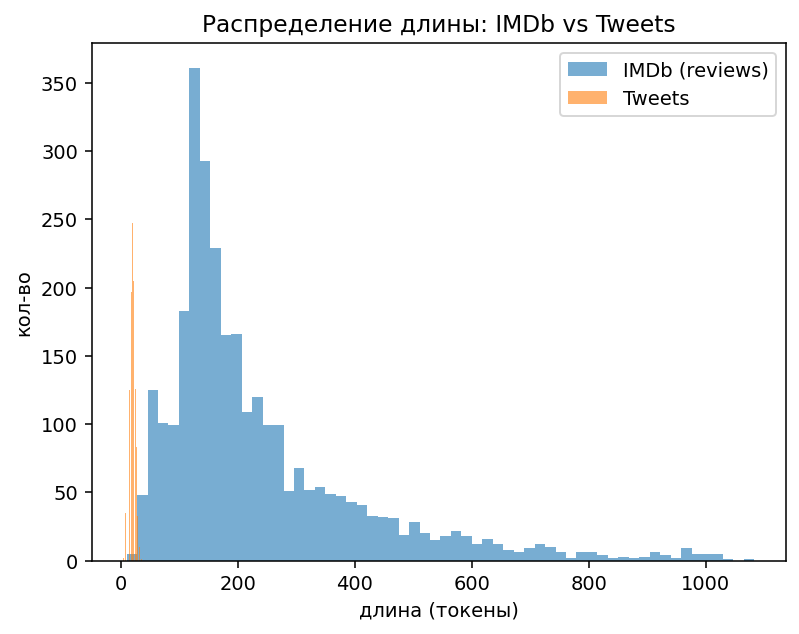

In [ ]:
# A5.4) Распределение длины документов: IMDb vs Tweets

plt.figure()
plt.hist([len(simple_tokenize(t)) for t in imdb_train], bins=60, alpha=0.6, label="IMDb (reviews)")
plt.hist([len(simple_tokenize(t)) for t in tweet_train], bins=60, alpha=0.6, label="Tweets")
plt.legend()
plt.title("Распределение длины: IMDb vs Tweets")
plt.xlabel("длина (токены)")
plt.ylabel("кол-во")
plt.show()


# Часть B — Наивный Байес, метрики и перенос (prose → poetry)

Мы сделаем задачу «кто автор?».

Авторы и тексты (Project Gutenberg):
- **Edgar Allan Poe**
  - проза: *Tales of Mystery and Imagination* (ID 2148)
  - поэзия: *The Raven and Other Poems* (ID 1065)
- **Oscar Wilde**
  - проза: *The Picture of Dorian Gray* (ID 174)
  - поэзия: *Poems* (ID 1057)

Чтобы поэзии было достаточно, мы:
- уменьшим `CHUNK_SIZE`,
- и будем сохранять хвост, если он >= 50% чанка.


In [ ]:
# B1) Скачиваем тексты (может занять 10–30 секунд)

POE_PROSE_ID = 2148
POE_POETRY_ID = 1065
WILDE_PROSE_ID = 174
WILDE_POETRY_ID = 1057

poe_prose = download_gutenberg_text(POE_PROSE_ID)
poe_poetry = download_gutenberg_text(POE_POETRY_ID)
wilde_prose = download_gutenberg_text(WILDE_PROSE_ID)
wilde_poetry = download_gutenberg_text(WILDE_POETRY_ID)

print("Скачано символов:")
print("Poe prose:", len(poe_prose))
print("Poe poetry:", len(poe_poetry))
print("Wilde prose:", len(wilde_prose))
print("Wilde poetry:", len(wilde_poetry))


Скачано символов:
Poe prose: 612436
Poe poetry: 7262
Wilde prose: 437855
Wilde poetry: 242106


In [ ]:
# B2) Режем на чанки

CHUNK_SIZE = 120  # меньше -> больше документов; попробуйте 80..200

def make_chunks(text: str, chunk_size: int) -> List[str]:
    toks = simple_tokenize(text)
    return chunk_tokens(toks, chunk_size=chunk_size, min_frac=0.5)

poe_prose_chunks = make_chunks(poe_prose, CHUNK_SIZE)
wilde_prose_chunks = make_chunks(wilde_prose, CHUNK_SIZE)

poe_poetry_chunks = make_chunks(poe_poetry, CHUNK_SIZE)
wilde_poetry_chunks = make_chunks(wilde_poetry, CHUNK_SIZE)

print("Чанки (проза):", len(poe_prose_chunks), len(wilde_prose_chunks))
print("Чанки (поэзия):", len(poe_poetry_chunks), len(wilde_poetry_chunks))

# метки: 0 = Poe, 1 = Wilde
X_prose = poe_prose_chunks + wilde_prose_chunks
y_prose = np.array([0]*len(poe_prose_chunks) + [1]*len(wilde_prose_chunks))

X_poetry = poe_poetry_chunks + wilde_poetry_chunks
y_poetry = np.array([0]*len(poe_poetry_chunks) + [1]*len(wilde_poetry_chunks))

author_names = ["Poe", "Wilde"]


Чанки (проза): 808 671
Чанки (поэзия): 9 320


In [ ]:
# B3) Train/Valid split (внутридоменный: проза → проза)

Xtr, Xva, ytr, yva = train_test_split(
    X_prose, y_prose, test_size=0.25, random_state=RANDOM_STATE, stratify=y_prose
)

print("Train chunks:", len(Xtr), "Valid chunks:", len(Xva))


Train chunks: 1109 Valid chunks: 370


In [ ]:
# B4-baseline) Multinomial NB (counts) — без предобработки

nb_counts_base = Pipeline([
    ("vec", CountVectorizer(
        # всё по умолчанию:
        # lowercase=True, token_pattern=...,
        # stop_words=None, min_df=1, max_df=1.0, ngram_range=(1,1)
    )),
    ("nb", MultinomialNB(alpha=0.1)),
])

nb_counts_base.fit(Xtr, ytr)
pred_va_base = nb_counts_base.predict(Xva)

print("BASE In-domain (PROSE→PROSE) accuracy:", accuracy_score(yva, pred_va_base))
print(classification_report(yva, pred_va_base, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(yva, pred_va_base))


BASE In-domain (PROSE→PROSE) accuracy: 0.9837837837837838
              precision    recall  f1-score   support

         Poe       0.98      0.99      0.99       202
       Wilde       0.99      0.98      0.98       168

    accuracy                           0.98       370
   macro avg       0.98      0.98      0.98       370
weighted avg       0.98      0.98      0.98       370

Confusion matrix:
 [[200   2]
 [  4 164]]


In [ ]:
# B5) Самые важные токены для NB: Δ(w)=logP(w|Poe)-logP(w|Wilde)

vec = nb_counts_base.named_steps["vec"]
clf = nb_counts_base.named_steps["nb"]
feature_names = np.array(vec.get_feature_names_out())

delta = clf.feature_log_prob_[0] - clf.feature_log_prob_[1]

top_n = 30
top_poe = np.argsort(-delta)[:top_n]
top_wilde = np.argsort(delta)[:top_n]  # самые отрицательные

df_poe = pd.DataFrame({"token": feature_names[top_poe], "Δ": delta[top_poe]})
df_wilde = pd.DataFrame({"token": feature_names[top_wilde], "Δ": delta[top_wilde]})

print("Топ-токены для Poe")
display(df_poe)
print("Топ-токены для Wilde")
display(df_wilde)

Топ-токены для Poe


,token,Δ
0,length,6.593206
1,altogether,5.728350
2,general,5.583589
3,scarcely,5.519259
4,vast,5.485472
5,valley,5.450503
6,portion,5.450503
7,arose,5.414267
8,extent,5.376669
9,observed,5.296945


Топ-токены для Wilde


,token,Δ
0,dorian,-8.217610
1,harry,-7.389023
2,basil,-7.173494
3,cried,-6.696621
4,sibyl,-6.635158
5,hallward,-6.552602
6,duchess,-6.181813
7,vane,-6.156559
8,lad,-6.019734
9,charming,-5.861175


## B4. Предобработка и модель

Добавим более «практичную» предобработку:
- удаление стоп-слов (встроенный список английских),
- фильтрация слишком частых слов `max_df`,
- фильтрация редких `min_df`,
- добавим биграммы (1,2) — часто помогает на авторстве.


In [ ]:
# B4) Multinomial NB (counts) + улучшенная предобработка

nb_counts = Pipeline([
    ("vec", CountVectorizer(
        stop_words="english",
        min_df=5,
        max_df=0.9,
        ngram_range=(1,2)
    )),
    ("nb", MultinomialNB(alpha=0.1)),
])

nb_counts.fit(Xtr, ytr)
pred_va = nb_counts.predict(Xva)

print("In-domain (PROSE→PROSE) accuracy:", accuracy_score(yva, pred_va))
print(classification_report(yva, pred_va, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(yva, pred_va))


In-domain (PROSE→PROSE) accuracy: 0.9837837837837838
              precision    recall  f1-score   support

         Poe       0.98      1.00      0.99       202
       Wilde       0.99      0.97      0.98       168

    accuracy                           0.98       370
   macro avg       0.98      0.98      0.98       370
weighted avg       0.98      0.98      0.98       370

Confusion matrix:
 [[201   1]
 [  5 163]]


In [ ]:
# B5) Самые важные токены для NB: Δ(w)=logP(w|Poe)-logP(w|Wilde)

vec = nb_counts.named_steps["vec"]
clf = nb_counts.named_steps["nb"]
feature_names = np.array(vec.get_feature_names_out())

delta = clf.feature_log_prob_[0] - clf.feature_log_prob_[1]

top_n = 30
top_poe = np.argsort(-delta)[:top_n]
top_wilde = np.argsort(delta)[:top_n]  # самые отрицательные

df_poe = pd.DataFrame({"token": feature_names[top_poe], "Δ": delta[top_poe]})
df_wilde = pd.DataFrame({"token": feature_names[top_wilde], "Δ": delta[top_wilde]})

print("Топ-токены для Poe")
display(df_poe)
print("Топ-токены для Wilde")
display(df_wilde)


Топ-токены для Poe


,token,Δ
0,length,6.762391
1,altogether,5.897535
2,general,5.752774
3,scarcely,5.688443
4,vast,5.654656
5,portion,5.619688
6,valley,5.619688
7,arose,5.583452
8,extent,5.545853
9,observed,5.466130


Топ-токены для Wilde


,token,Δ
0,dorian,-8.048426
1,lord henry,-7.445811
2,harry,-7.219838
3,dorian gray,-7.013517
4,basil,-7.004309
5,cried,-6.527436
6,sibyl,-6.465973
7,hallward,-6.383418
8,duchess,-6.012629
9,vane,-5.987375


In [ ]:
# B6) Domain shift: обучаемся на прозе, тестируемся на поэзии

pred_poetry = nb_counts.predict(X_poetry)

print("Domain shift (PROSE→POETRY) accuracy:", accuracy_score(y_poetry, pred_poetry))
print(classification_report(y_poetry, pred_poetry, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(y_poetry, pred_poetry))


Domain shift (PROSE→POETRY) accuracy: 0.5167173252279635
              precision    recall  f1-score   support

         Poe       0.04      0.78      0.08         9
       Wilde       0.99      0.51      0.67       320

    accuracy                           0.52       329
   macro avg       0.52      0.64      0.38       329
weighted avg       0.96      0.52      0.66       329

Confusion matrix:
 [[  7   2]
 [157 163]]


In [ ]:
# B7) Сравнение: TF-IDF + NB и ComplementNB

nb_tfidf = Pipeline([
    ("vec", TfidfVectorizer(
        stop_words="english",
        min_df=5,
        max_df=0.9,
        ngram_range=(1,2)
    )),
    ("nb", MultinomialNB(alpha=0.1)),
])

nb_tfidf.fit(Xtr, ytr)
print("TF-IDF NB: In-domain acc:", accuracy_score(yva, nb_tfidf.predict(Xva)))
print("TF-IDF NB: PROSE→POETRY acc:", accuracy_score(y_poetry, nb_tfidf.predict(X_poetry)))

comp_tfidf = Pipeline([
    ("vec", TfidfVectorizer(
        stop_words="english",
        min_df=5,
        max_df=0.9,
        ngram_range=(1,2)
    )),
    ("nb", ComplementNB(alpha=0.1)),
])

comp_tfidf.fit(Xtr, ytr)
print("ComplementNB: In-domain acc:", accuracy_score(yva, comp_tfidf.predict(Xva)))
print("ComplementNB: PROSE→POETRY acc:", accuracy_score(y_poetry, comp_tfidf.predict(X_poetry)))


TF-IDF NB: In-domain acc: 0.981081081081081
TF-IDF NB: PROSE→POETRY acc: 0.5775075987841946
ComplementNB: In-domain acc: 0.9783783783783784
ComplementNB: PROSE→POETRY acc: 0.6382978723404256


## Кратко про метрики

Для бинарной классификации класса “+”:
- precision = TP / (TP + FP)
- recall = TP / (TP + FN)
- F1 = 2 · precision · recall / (precision + recall)

Для многоклассовой:
- Macro-F1 — среднее F1 по классам
- Micro-F1 — считаем TP/FP/FN глобально (в single-label часто совпадает с accuracy)

В ноутбуке метрики печатает `classification_report`.


# Домашка

## Часть A — Domain shift / распределения
1) Выберите датасет на русском  языке и два домена (2 темы из одного датасета, или 2 датасета HF, или свои тексты. Вариант датасета: https://huggingface.co/datasets/data-silence/rus_news_classifier).
2) Посчитайте **top-30 log-odds** токенов (в обе стороны).
3) Нарисуйте хотя бы 2 графика распределений (на выбор):
   - длина документов,
   - Zipf (частоты топ-100 токенов),
   - доля чисел/пунктуации,
   - размер словаря.
4) добавьте лемматизацию, n-граммы, стоп-слова, и сравните важные токены.
5) Напишите 5–10 наблюдений: что изменилось и почему.

## Часть B — Наивный Байес + оценка
1) Выберите 2 автора (русский).
2) Нарежьте тексты на чанки (80–300 токенов).
3) Обучите MultinomialNB и отчитайтесь:
   - confusion matrix,
   - precision/recall/F1.
4) Покажите **top-20 важнейших токенов** на основе Δ(w).
5) добавьте лемматизацию, n-граммы, стоп-слова, и сравните важные токены.
6) Сделайте domain shift (например, проза → стихи / письма / пьесы) и опишите, что сломалось и что помогло.

